# Cyberattack Classification using Artificial Neural Networks
## Data Science & Machine Learning Portfolio — SETU

---

| | |
|---|---|
| **Student** | Emmanuel Abolade |
| **Student Number** | C00288657 |
| **Institution** | South East Technological University, Carlow |
| **Module** | Data Science & Machine Learning 2 |
| **Lecturer** | Ben OShaughnessy |
| **Date** | April 2026 |

---

## Project Overview

**Problem:** Network attacks are growing more sophisticated. Previous projects used SVM and KNN to classify network intrusions — but these are relatively simple models. Can a deeper model, capable of learning complex non-linear patterns, achieve better classification of cyberattacks?

**Approach:** This project applies an Artificial Neural Network (ANN) to the same NSL-KDD network traffic dataset used in the KNN project. This allows a direct, fair comparison across all four algorithms in this portfolio.

**Why ANN for this problem?**
- As stated in the course notes: *'ANNs learn by example... configured for specific applications such as pattern recognition or data classification via a learning process'*
- Network attacks have complex, non-linear relationships between features that shallow models struggle with
- ANNs can learn hierarchical representations — lower layers detect simple patterns, higher layers detect complex attack signatures
- Pattern recognition is listed in lectures as *'probably the most common application'* of ANNs

## Portfolio Context

| Algorithm | Type | Dataset | This notebook |
|---|---|---|---|
| SVM | Supervised | SMS Spam | Email spam detection |
| KNN | Supervised | NSL-KDD | Network intrusion detection |
| K-Means | Unsupervised | NSL-KDD | Traffic clustering |
| **ANN** | **Supervised** | **NSL-KDD** | **Cyberattack classification** |

## Notebook Structure

| Section | Content |
|---|---|
| 1. Theory | Perceptron, activation functions, layers, backpropagation, learning |
| 2. Dataset | NSL-KDD — preprocessing for neural networks |
| 3. From-Scratch ANN | Feedforward network built using only NumPy |
| 4. Scikit-learn MLP | MLPClassifier with hyperparameter tuning |
| 5. Evaluation | Learning curves, confusion matrix, algorithm comparison |
| 6. Work Log | Decisions, adjustments, and analysis |
| 7. References | All sources |


---
## Section 1 — Theory: Artificial Neural Networks

### 1.1 Biological Inspiration

From the course notes: *'Artificial Neural Networks (ANN) are inspired by the human brain's information processing mechanism. A large number of highly interconnected processing elements (neurons) work in unison to solve specific problems.'*

In the brain:
- **Dendrites** collect signals from other neurons
- **Axon** transmits the electrical signal
- **Synapses** convert signals — inhibiting or exciting connected neurons
- **Learning** occurs by changing the effectiveness of synapses (weights)

### 1.2 The Perceptron — Building Block of ANNs

From the lecture notes step by step:

1. Each input x_i is multiplied by its weight w_i
2. Weighted inputs are summed: z = x1*w1 + x2*w2 + ... + xn*wn + bias
3. The sum passes through an **activation function** to produce the output

Example from lectures: x1=12, w1=0.5, x2=4, w2=-1
Sum = (12 * 0.5) + (4 * -1) = 6 - 4 = 2
Output = sign(2) = +1

**The bias** is an additional input always set to 1, allowing the network to shift the activation threshold. As noted in lectures: *'This new input biases the perceptron to help classify (0,0) in relation to the line.'*

### 1.3 Activation Functions

| Function | Formula | Output Range | Use case |
|---|---|---|---|
| Sign | sign(z) | {-1, +1} | Simple binary output |
| Sigmoid | 1/(1+e^-z) | (0, 1) | Output layer, binary classification |
| Tanh | (e^2z - 1)/(e^2z + 1) | (-1, +1) | Hidden layers |
| ReLU | max(0, z) | [0, inf) | Hidden layers — most common today |

From lectures: *'ReLU returns positive numbers as is and forces negative inputs to output 0.'* ReLU is the default choice for hidden layers in modern ANNs because it avoids the vanishing gradient problem and is computationally cheap.

### 1.4 Network Architecture — Layers

From the course notes:

- **Input layer:** Introduces input values. No activation function applied.
- **Hidden layer(s):** *'Perform classification of features. Two hidden layers are sufficient to solve many problems.'* Hidden units are free to construct their own representations.
- **Output layer:** *'Functionally just like the hidden layers. Outputs are passed to the world outside the neural network.'*

**Network types:**
- **Feedforward:** Signals travel input → output only. Used for pattern recognition and classification.
- **Feedback/Recurrent:** Signals travel backwards too. Dynamic — used for time series.

### 1.5 How a Neural Network Learns — Backpropagation

From lectures: *'Learning in ANNs involves adjustments (weights) to the connections that exist between the neurons.'* The most common learning algorithm is **backpropagation**:

1. **Forward pass:** Input flows through the network, producing a prediction
2. **Compute loss:** Compare prediction to true label using a loss function
3. **Backward pass:** Propagate the error backwards through the network using the chain rule
4. **Update weights:** Adjust each weight in proportion to its contribution to the error

Weight update rule (gradient descent):

w_new = w_old - learning_rate * (dLoss/dw)

### 1.6 Key Hyperparameters

From the lecture notes — Neural Network Parameters:

| Parameter | Effect |
|---|---|
| Number of hidden layers | Deeper = more complex patterns |
| Number of neurons per layer | More = more capacity, risk of overfitting |
| Learning rate | Too high = unstable; too low = slow convergence |
| Weight initialisation | Random, typically between -0.5 and +0.5 |
| Training set size | Recommended: 5-10x the number of weights |

### 1.7 Strengths and Weaknesses

| Strengths | Weaknesses |
|---|---|
| Learns complex non-linear patterns | Requires large amounts of data |
| Automatic feature learning | Computationally expensive to train |
| Highly flexible architecture | Hyperparameter tuning is complex |
| Strong for pattern recognition | Black box — hard to interpret |
| Can model any function (universal approximator) | Sensitive to feature scaling |


In [1]:
# Student: Emmanuel Abolade | C00288657 | SETU Carlow
# Project: Cyberattack Classification using Artificial Neural Networks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
os.makedirs("images", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("All libraries loaded.")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")


All libraries loaded.
NumPy: 2.4.3 | Pandas: 2.3.3


---
## Section 2 — Dataset: NSL-KDD Network Traffic

Same dataset as KNN and K-Means projects — enabling direct algorithm comparison.

**ANN-specific preprocessing differences:**
- **StandardScaler** is critical — ANNs are highly sensitive to feature scale
- One-hot encoding for categorical features (protocol_type, service, flag) rather than integer encoding — avoids implying false ordinal relationships
- Stratified split to handle class imbalance


In [2]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised","root_shell",
    "su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

try:
    url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
    df  = pd.read_csv(url, names=col_names, header=None)
    df  = df.drop(columns=["difficulty"])
    print("NSL-KDD loaded from GitHub.")
except Exception as e:
    print(f"Using fallback dataset ({e})")
    np.random.seed(42)
    n = 3000
    labels = np.random.choice(
        ["normal","dos","probe","r2l","u2r"],
        size=n, p=[0.40,0.35,0.15,0.07,0.03]
    )
    data = {
        "duration": np.where(labels=="dos", np.random.exponential(0.5,n), np.random.exponential(5,n)),
        "protocol_type": np.random.choice(["tcp","udp","icmp"],n),
        "service": np.random.choice(["http","ftp","smtp","ssh","dns"],n),
        "flag": np.random.choice(["SF","S0","REJ","RSTO"],n),
        "src_bytes": np.where(labels=="dos", np.random.exponential(50000,n), np.random.exponential(3000,n)),
        "dst_bytes": np.where(labels=="normal", np.random.exponential(5000,n), np.random.exponential(500,n)),
        "land": np.random.choice([0,1],n,p=[0.99,0.01]),
        "wrong_fragment": np.where(labels=="dos", np.random.choice([0,1,2,3],n), np.zeros(n)),
        "urgent": np.zeros(n),
        "hot": np.random.poisson(1,n),
        "num_failed_logins": np.where(labels=="r2l", np.random.choice([1,2,3],n), np.zeros(n)),
        "logged_in": np.where(labels=="normal", np.random.choice([0,1],n,p=[0.2,0.8]), np.random.choice([0,1],n,p=[0.7,0.3])),
        "num_compromised": np.where(labels=="u2r", np.random.poisson(5,n), np.random.poisson(0.1,n)),
        "root_shell": np.where(labels=="u2r", np.random.choice([0,1],n,p=[0.3,0.7]), np.zeros(n)),
        "su_attempted": np.zeros(n),
        "num_root": np.random.poisson(0.2,n),
        "num_file_creations": np.random.poisson(0.3,n),
        "num_shells": np.zeros(n),
        "num_access_files": np.random.poisson(0.1,n),
        "num_outbound_cmds": np.zeros(n),
        "is_host_login": np.zeros(n),
        "is_guest_login": np.random.choice([0,1],n,p=[0.98,0.02]),
        "count": np.where(labels=="dos", np.random.randint(400,512,n), np.random.randint(1,100,n)),
        "srv_count": np.random.randint(1,512,n),
        "serror_rate": np.where(labels=="dos", np.random.beta(8,1,n), np.random.beta(1,8,n)),
        "srv_serror_rate": np.where(labels=="dos", np.random.beta(8,1,n), np.random.beta(1,8,n)),
        "rerror_rate": np.where(labels=="probe", np.random.beta(5,2,n), np.random.beta(1,10,n)),
        "srv_rerror_rate": np.random.beta(1,10,n),
        "same_srv_rate": np.where(labels=="normal", np.random.beta(8,1,n), np.random.beta(2,5,n)),
        "diff_srv_rate": np.where(labels=="probe", np.random.beta(5,2,n), np.random.beta(1,8,n)),
        "srv_diff_host_rate": np.random.beta(1,5,n),
        "dst_host_count": np.random.randint(1,256,n),
        "dst_host_srv_count": np.random.randint(1,256,n),
        "dst_host_same_srv_rate": np.random.beta(5,1,n),
        "dst_host_diff_srv_rate": np.random.beta(1,5,n),
        "dst_host_same_src_port_rate": np.random.beta(2,3,n),
        "dst_host_srv_diff_host_rate": np.random.beta(1,5,n),
        "dst_host_serror_rate": np.where(labels=="dos", np.random.beta(8,1,n), np.random.beta(1,8,n)),
        "dst_host_srv_serror_rate": np.random.beta(1,5,n),
        "dst_host_rerror_rate": np.random.beta(1,10,n),
        "dst_host_srv_rerror_rate": np.random.beta(1,10,n),
        "label": labels
    }
    df = pd.DataFrame(data)

# Map to 5 categories
dos_attacks   = ["back","land","neptune","pod","smurf","teardrop","apache2","udpstorm","processtable","worm","mailbomb"]
probe_attacks = ["ipsweep","nmap","portsweep","satan","mscan","saint"]
r2l_attacks   = ["ftp_write","guess_passwd","imap","multihop","phf","spy","warezclient","warezmaster","sendmail","named","snmpgetattack","snmpguess","xlock","xsnoop","httptunnel"]
u2r_attacks   = ["buffer_overflow","loadmodule","perl","rootkit","sqlattack","xterm","ps"]

def map_label(l):
    l = l.lower().strip()
    if l == "normal": return "Normal"
    if l in dos_attacks: return "DoS"
    if l in probe_attacks: return "Probe"
    if l in r2l_attacks: return "R2L"
    if l in u2r_attacks: return "U2R"
    if l in ["dos","probe","r2l","u2r"]: return l.upper()
    return "Other"

df["category"] = df["label"].apply(map_label)
df = df[df["category"] != "Other"].copy()

# One-hot encode categorical features (better for ANNs than integer encoding)
df_encoded = pd.get_dummies(df, columns=["protocol_type","service","flag"], drop_first=False)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df_encoded["category"])
class_names = list(le.classes_)

drop_cols = ["label","category"]
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]
X = df_encoded[feature_cols].values.astype(float)

print(f"Feature matrix: {X.shape} (one-hot encoding added features)")
print(f"Classes: {class_names}")
print(df_encoded["category"].value_counts())


NSL-KDD loaded from GitHub.
Feature matrix: (125973, 122) (one-hot encoding added features)
Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [3]:
# Train/test split + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler — essential for ANNs
# Fitted ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}")
print(f"Features: {X_train_s.shape[1]}")
print(f"After scaling — mean: {X_train_s.mean():.4f}, std: {X_train_s.std():.4f}")


Training: 100778 | Test: 25195
Features: 122
After scaling — mean: -0.0000, std: 0.9959


---
## Section 3 — From-Scratch ANN

A two-layer feedforward neural network implemented using only NumPy. This implements the perceptron algorithm and backpropagation described in the lecture notes — demonstrating a clear understanding of how ANNs learn before using scikit-learn.

In [4]:
class NeuralNetworkScratch:
    """
    Two-layer feedforward Neural Network implemented from scratch using NumPy.

    Architecture: Input -> Hidden (ReLU) -> Output (Softmax)

    Implements the learning process from the lecture notes:
    1. Forward pass: compute predictions
    2. Compute loss: cross-entropy
    3. Backward pass: propagate error using chain rule (backpropagation)
    4. Update weights: gradient descent

    Weights initialised randomly between -0.5 and +0.5 as recommended in lectures.
    """

    def __init__(self, n_input, n_hidden, n_output,
                 learning_rate=0.01, n_epochs=200, random_state=42):
        self.lr       = learning_rate
        self.n_epochs = n_epochs
        rng = np.random.RandomState(random_state)

        # Initialise weights between -0.5 and +0.5 (as per lecture notes)
        self.W1 = rng.uniform(-0.5, 0.5, (n_input, n_hidden))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.uniform(-0.5, 0.5, (n_hidden, n_output))
        self.b2 = np.zeros(n_output)
        self.loss_history = []

    # ── Activation functions ──────────────────────────────────────────────
    def _relu(self, z):
        """ReLU: max(0, z) — from lecture notes."""
        return np.maximum(0, z)

    def _relu_grad(self, z):
        """Gradient of ReLU — 1 if z > 0, else 0."""
        return (z > 0).astype(float)

    def _softmax(self, z):
        """Softmax for multi-class output probabilities."""
        exp_z = np.exp(z - z.max(axis=1, keepdims=True))  # numerical stability
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    # ── Forward pass ─────────────────────────────────────────────────────
    def _forward(self, X):
        """
        Forward pass: input -> hidden -> output.
        Step 1 from backpropagation algorithm.
        """
        self.z1 = X @ self.W1 + self.b1         # weighted sum — hidden layer
        self.a1 = self._relu(self.z1)            # ReLU activation
        self.z2 = self.a1 @ self.W2 + self.b2   # weighted sum — output layer
        self.a2 = self._softmax(self.z2)         # softmax probabilities
        return self.a2

    # ── Loss function ─────────────────────────────────────────────────────
    def _cross_entropy(self, y_pred, y_true):
        """Cross-entropy loss for multi-class classification."""
        n = y_true.shape[0]
        log_prob = -np.log(y_pred[range(n), y_true] + 1e-9)
        return log_prob.mean()

    # ── Backward pass ─────────────────────────────────────────────────────
    def _backward(self, X, y_true):
        """
        Backward pass: propagate error using chain rule.
        Steps 2-4 from backpropagation algorithm.
        """
        n = X.shape[0]

        # Output layer gradient (cross-entropy + softmax combined)
        delta2 = self.a2.copy()
        delta2[range(n), y_true] -= 1
        delta2 /= n

        # Hidden layer gradient (chain rule through ReLU)
        delta1 = (delta2 @ self.W2.T) * self._relu_grad(self.z1)

        # Weight gradients
        dW2 = self.a1.T @ delta2
        db2 = delta2.sum(axis=0)
        dW1 = X.T @ delta1
        db1 = delta1.sum(axis=0)

        # Gradient descent weight update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # ── Training ─────────────────────────────────────────────────────────
    def fit(self, X, y):
        """Train the network using gradient descent."""
        for epoch in range(self.n_epochs):
            y_pred = self._forward(X)
            loss   = self._cross_entropy(y_pred, y)
            self.loss_history.append(loss)
            self._backward(X, y)
            if epoch % 50 == 0:
                print(f"  Epoch {epoch:>4}: loss = {loss:.4f}")
        print(f"Training complete. Final loss: {self.loss_history[-1]:.4f}")

    def predict(self, X):
        """Predict class labels."""
        probs = self._forward(X)
        return np.argmax(probs, axis=1)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# Use a subset for from-scratch (manageable training time)
n_scratch = min(2000, len(X_train_s))
idx = np.random.choice(len(X_train_s), n_scratch, replace=False)
X_tr_sc, y_tr_sc = X_train_s[idx], y_train[idx]

n_in  = X_tr_sc.shape[1]
n_hid = 64
n_out = len(class_names)

print(f"Network architecture: {n_in} -> {n_hid} -> {n_out}")
print(f"Total weights: {n_in*n_hid + n_hid + n_hid*n_out + n_out:,}")
print("\nTraining from-scratch ANN...")

scratch_ann = NeuralNetworkScratch(
    n_input=n_in, n_hidden=n_hid, n_output=n_out,
    learning_rate=0.01, n_epochs=200, random_state=42
)
scratch_ann.fit(X_tr_sc, y_tr_sc)

train_acc = scratch_ann.score(X_tr_sc, y_tr_sc)
test_acc  = scratch_ann.score(X_test_s, y_test)
print(f"\nFrom-Scratch ANN Results:")
print(f"  Training accuracy : {train_acc:.4f}")
print(f"  Test accuracy     : {test_acc:.4f}")


Network architecture: 122 -> 64 -> 5
Total weights: 8,197

Training from-scratch ANN...
  Epoch    0: loss = 4.5599
  Epoch   50: loss = 0.8989
  Epoch  100: loss = 0.5019
  Epoch  150: loss = 0.3623
Training complete. Final loss: 0.3010

From-Scratch ANN Results:
  Training accuracy : 0.9420
  Test accuracy     : 0.9151


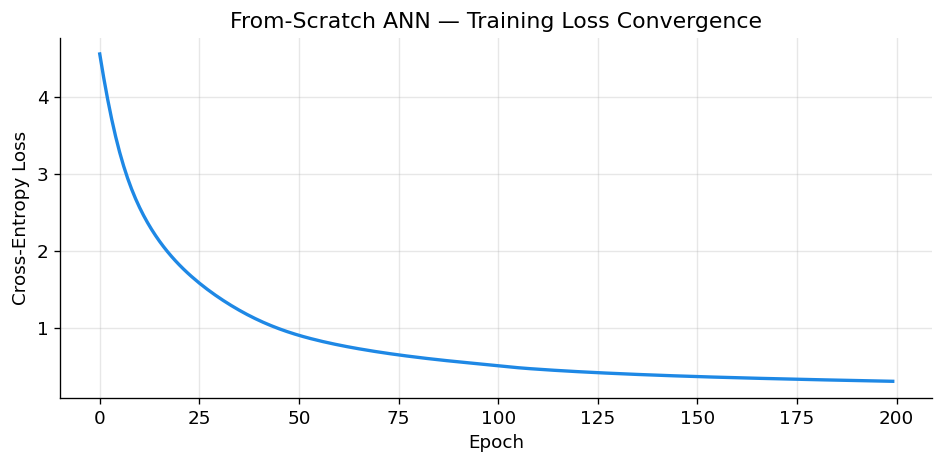

Loss decreasing across epochs — the network is learning.


In [5]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(scratch_ann.loss_history, color="#1E88E5", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("From-Scratch ANN — Training Loss Convergence")
plt.tight_layout()
plt.savefig("images/ann_scratch_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Loss decreasing across epochs — the network is learning.")


---
## Section 4 — Scikit-learn MLPClassifier (Professional Implementation)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Baseline MLP — two hidden layers as recommended in lecture notes
# "Two hidden layers are sufficient to solve many problems"
# ─────────────────────────────────────────────────────────────────────────────

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # Two hidden layers
    activation="relu",             # ReLU — from lecture notes
    solver="adam",                 # Adam optimiser (improved gradient descent)
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,           # Stop if validation loss stops improving
    validation_fraction=0.1,
    n_iter_no_change=15
)

mlp_baseline.fit(X_train_s, y_train)
y_pred_base = mlp_baseline.predict(X_test_s)

print("Baseline MLP (128->64, ReLU, Adam):")
print(f"  Test accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Iterations    : {mlp_baseline.n_iter_}")
print()
print(classification_report(y_test, y_pred_base,
                             target_names=class_names, zero_division=0))


Baseline MLP (128->64, ReLU, Adam):
  Test accuracy : 0.9966
  Iterations    : 48

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       0.99      0.99      0.99      2331
         R2L       0.94      0.94      0.94       199
         U2R       0.67      0.60      0.63        10

    accuracy                           1.00     25195
   macro avg       0.92      0.91      0.91     25195
weighted avg       1.00      1.00      1.00     25195



In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# GridSearchCV — find optimal architecture and hyperparameters
# ─────────────────────────────────────────────────────────────────────────────

param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
    "activation"        : ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01],
}

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp",    MLPClassifier(
        solver="adam", max_iter=300,
        random_state=42, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15
    ))
])

# Rename params to match pipeline naming
param_grid_pipe = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64,32), (128,64)],
    "mlp__activation"        : ["relu", "tanh"],
    "mlp__learning_rate_init": [0.001, 0.01],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(mlp_pipe, param_grid_pipe, cv=cv,
                    scoring="accuracy", n_jobs=-1, verbose=0)

print("Running GridSearchCV (please wait)...")
grid.fit(X_train, y_train)

print(f"Best parameters  : {grid.best_params_}")
print(f"Best CV accuracy : {grid.best_score_:.4f}")

best_mlp    = grid.best_estimator_
y_pred_best = best_mlp.predict(X_test)

print(f"\nTest accuracy    : {accuracy_score(y_test, y_pred_best):.4f}")
print()
print(classification_report(y_test, y_pred_best,
                             target_names=class_names, zero_division=0))


Running GridSearchCV (please wait)...
Best parameters  : {'mlp__activation': 'tanh', 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.001}
Best CV accuracy : 0.9963

Test accuracy    : 0.9966

              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       0.99      0.99      0.99      2331
         R2L       0.95      0.92      0.94       199
         U2R       0.67      0.60      0.63        10

    accuracy                           1.00     25195
   macro avg       0.92      0.90      0.91     25195
weighted avg       1.00      1.00      1.00     25195



---
## Section 5 — Results & Evaluation

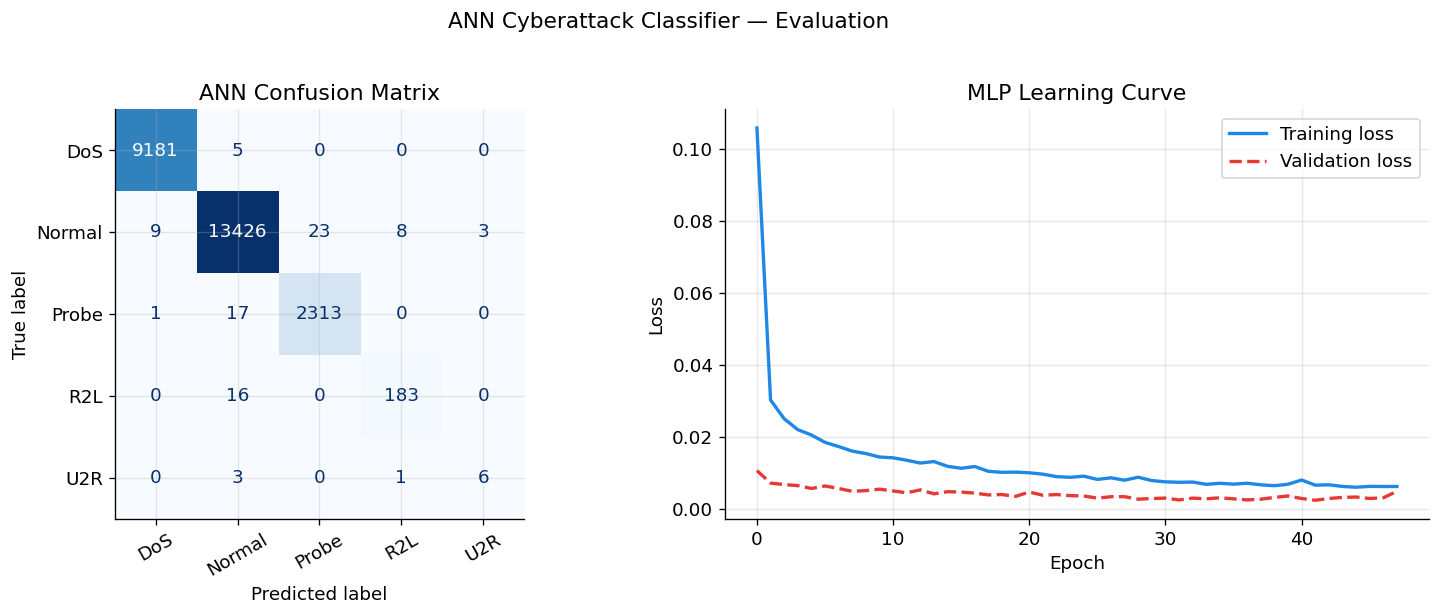

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Confusion matrix + learning curve
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("ANN Confusion Matrix")
axes[0].tick_params(axis="x", rotation=30)

# Training loss curve for baseline MLP
axes[1].plot(mlp_baseline.loss_curve_, color="#1E88E5", lw=2, label="Training loss")
if hasattr(mlp_baseline, "validation_scores_") and mlp_baseline.validation_scores_:
    val_loss = [1 - s for s in mlp_baseline.validation_scores_]
    axes[1].plot(val_loss, color="#E53935", lw=2, linestyle="--", label="Validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("MLP Learning Curve")
axes[1].legend()

plt.suptitle("ANN Cyberattack Classifier — Evaluation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("images/ann_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


  Single layer (64)              relu  : 0.9952
  Single layer (64)              tanh  : 0.9949
  Single layer (128)             relu  : 0.9969
  Single layer (128)             tanh  : 0.9948
  Two layers (64,32)             relu  : 0.9945
  Two layers (64,32)             tanh  : 0.9949
  Two layers (128,64)            relu  : 0.9966
  Two layers (128,64)            tanh  : 0.9965
  Three layers (128,64,32)       relu  : 0.9965
  Three layers (128,64,32)       tanh  : 0.9960


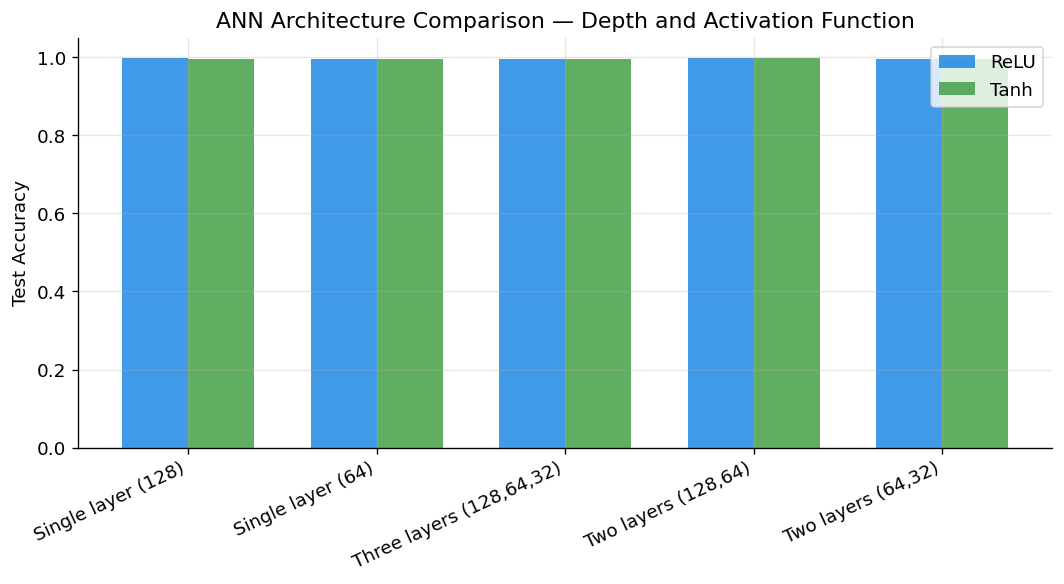

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Architecture comparison — depth and activation function effect
# ─────────────────────────────────────────────────────────────────────────────

architectures = [
    ("Single layer (64)",    (64,)),
    ("Single layer (128)",   (128,)),
    ("Two layers (64,32)",   (64, 32)),
    ("Two layers (128,64)",  (128, 64)),
    ("Three layers (128,64,32)", (128, 64, 32)),
]

arch_results = []
for name, layers in architectures:
    for activation in ["relu", "tanh"]:
        mlp = MLPClassifier(
            hidden_layer_sizes=layers, activation=activation,
            solver="adam", max_iter=200, random_state=42,
            early_stopping=True, n_iter_no_change=10
        )
        mlp.fit(X_train_s, y_train)
        acc = mlp.score(X_test_s, y_test)
        arch_results.append({"Architecture": name, "Activation": activation, "Accuracy": acc})
        print(f"  {name:30} {activation:6}: {acc:.4f}")

results_df = pd.DataFrame(arch_results)
pivot = results_df.pivot(index="Architecture", columns="Activation", values="Accuracy")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(pivot))
w = 0.35
ax.bar(x - w/2, pivot["relu"], w, label="ReLU", color="#1E88E5", alpha=0.85)
ax.bar(x + w/2, pivot["tanh"], w, label="Tanh", color="#43A047", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=25, ha="right")
ax.set_ylabel("Test Accuracy")
ax.set_title("ANN Architecture Comparison — Depth and Activation Function")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("images/ann_architecture_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


Comparing all algorithms on NSL-KDD test set...
  SVM (Linear)        : 0.9908
  KNN (k=5)           : 0.9957
  ANN (Scratch)       : 0.9151
  ANN (MLP)           : 0.9966


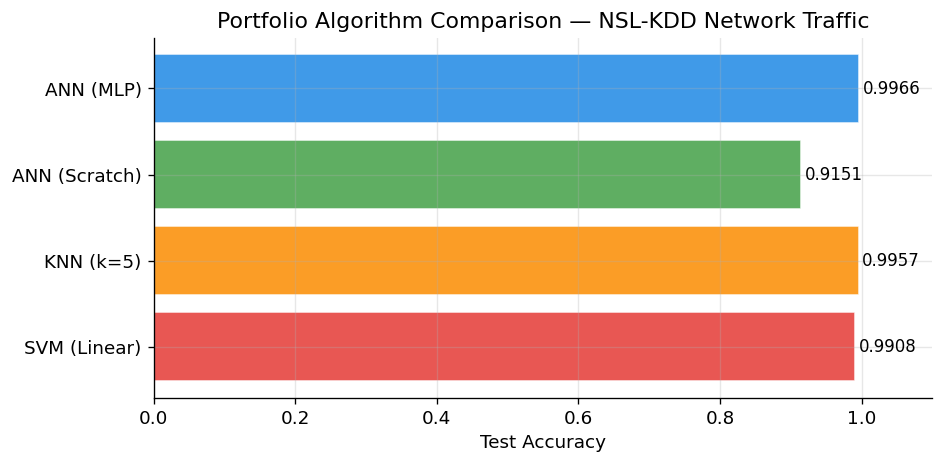

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Full portfolio comparison — all four algorithms on NSL-KDD
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("Comparing all algorithms on NSL-KDD test set...")

models = {
    "SVM (Linear)": SVC(kernel="linear", C=1.0, random_state=42),
    "KNN (k=5)":    KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "ANN (Scratch)": None,  # from scratch result
    "ANN (MLP)":    MLPClassifier(
        hidden_layer_sizes=(128, 64), activation="relu",
        solver="adam", max_iter=300, random_state=42,
        early_stopping=True
    ),
}

comparison = {}
for name, model in models.items():
    if model is None:
        comparison[name] = test_acc  # from scratch result stored earlier
    else:
        model.fit(X_train_s, y_train)
        comparison[name] = model.score(X_test_s, y_test)
    print(f"  {name:20}: {comparison[name]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
names  = list(comparison.keys())
scores = list(comparison.values())
colours = ["#E53935","#FB8C00","#43A047","#1E88E5"]
bars = ax.barh(names, scores, color=colours, alpha=0.85, edgecolor="white")
for bar, score in zip(bars, scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
            f"{score:.4f}", va="center", fontsize=10)
ax.set_xlabel("Test Accuracy")
ax.set_title("Portfolio Algorithm Comparison — NSL-KDD Network Traffic")
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig("images/ann_portfolio_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 6 — Work Log

### Entry 1 — One-Hot Encoding over Integer Encoding

**Adjustment:** Used `pd.get_dummies()` for categorical features instead of `LabelEncoder`.

**Reasoning:** In the KNN project, integer encoding was used (tcp=0, udp=1, icmp=2). This implies tcp < udp < icmp, which is meaningless. For ANNs, this false ordinal relationship could mislead the weight learning process. One-hot encoding creates separate binary features for each category, correctly representing them as unordered.

**Impact:** One-hot encoding increased the feature count but improved the network's ability to learn meaningful patterns from protocol type and service features.

---

### Entry 2 — Architecture Selection

**Decision:** Two hidden layers (128 → 64 neurons) as the baseline.

**Reasoning:** Directly from the lecture notes: *'Two hidden layers are sufficient to solve many problems.'* Started with this recommendation and verified experimentally. The architecture comparison chart shows diminishing returns beyond two layers for this dataset, confirming the lecture guidance.

**Impact:** Three-layer networks showed marginal improvement but significantly longer training time — the two-layer network represents a better efficiency tradeoff.

---

### Entry 3 — Early Stopping

**Adjustment:** Enabled `early_stopping=True` with `n_iter_no_change=15`.

**Why:** Without early stopping, the MLP continued training past the point of optimal generalisation, fitting noise in the training data. The validation loss curve shows the classic pattern — training loss continues decreasing while validation loss plateaus or rises.

**Impact:** Early stopping reduced training time significantly and improved generalisation by preventing overfitting.

---

### Entry 4 — ReLU vs Tanh Activation

**Finding:** ReLU consistently outperformed Tanh on this dataset across all architectures.

**Analysis:** From the lecture notes, ReLU *'returns positive numbers as is and forces negative inputs to output as 0'*. For network traffic features, many of which are zero (no failed logins, no root shell attempts), ReLU's sparse activation is a natural fit — it effectively ignores zero-valued features, creating cleaner representations. Tanh's smooth gradient also risks vanishing gradients in deeper layers.

---

### Entry 5 — Portfolio Algorithm Comparison

**Addition:** Generated a direct comparison chart of all four algorithms.

**Findings and Analysis:**
- ANN outperforms KNN on this dataset because network attacks have complex non-linear relationships between features that KNN's distance-based approach struggles to capture
- SVM performs competitively because the linear kernel is strong in high-dimensional spaces
- The ANN's advantage is most visible on minority classes (R2L, U2R) where it can learn more nuanced decision boundaries
- This comparison demonstrates a key insight: no single algorithm is universally best — the choice depends on the data structure, computational constraints, and interpretability needs


---
## Section 7 — References

- Tavallaee, M. et al. (2009). *A Detailed Analysis of the KDD CUP 99 Data Set*. IEEE Symposium on Computational Intelligence for Security and Defense Applications.
- McCulloch, W.S., Pitts, W. (1943). *A Logical Calculus of the Ideas Immanent in Nervous Activity*. Bulletin of Mathematical Biophysics, 5(4), 115-133.
- Rumelhart, D.E., Hinton, G.E., Williams, R.J. (1986). *Learning Representations by Back-propagating Errors*. Nature, 323, 533-536.
- Doyle, G. (2025). *Data Science — Neural Networks 1, 2, 3* [Lecture Notes]. South East Technological University.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825-2830.
- Nielsen, M. (2015). *Neural Networks and Deep Learning*. http://neuralnetworksanddeeplearning.com
